<a href="https://colab.research.google.com/github/gyanellaagreda-bd/MINERIA-DE-DATOS---2026-1/blob/main/AGREDA_LAB_S07_MDD_PSAYAN_2026_01Loan_Predic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💳 LABORATORIO N° 09 — Minería de Datos

## Predicción de Riesgo Crediticio — Loan Default Prediction (Finanzas)

| | |
|---|---|
| **Curso** | Minería de Datos — C64893 |
| **Semana** | 9 |
| **Docente** | Pilar Rocío Sayán Mejía |
| **Institución** | TECSUP — Pasión por la Tecnología |
| **Semestre** | 2026-I |

---

## 📋 Instrucciones generales

- Ejecuta **todas** las celdas de código en orden.
- Responde las preguntas en las celdas de texto (Markdown) asignadas.
- **Dataset:** Loan Default Prediction — variables socioeconómicas y financieras de solicitantes de préstamo.
- **Objetivo:** Construir un modelo de Regresión Logística para predecir si un préstamo será aprobado o si el solicitante tiene alto riesgo de incumplimiento (`Loan_Status`).


---
# ACTIVIDAD 1: Revisión de Conceptos — Clasificación y Riesgo Crediticio

Complete la tabla con definiciones propias. **No copie textualmente** de los materiales.

| N° | Concepto | Definición |
|---:|---|---|
| 1 | Riesgo crediticio | Es la posibilidad de que una persona o empresa no cumpla con el pago de un préstamo. En un banco, este riesgo se analiza antes de aprobar un crédito para evitar pérdidas. |
| 2 | Default / Incumplimiento | Ocurre cuando el cliente deja de pagar su deuda según lo pactado. En términos simples, es cuando el préstamo entra en mora o no se recupera el dinero prestado. |
| 3 | Clasificación binaria | Es un problema de Machine Learning donde el modelo predice entre dos posibles resultados. En este caso, puede ser préstamo aprobado o rechazado. |
| 4 | Variable objetivo | Es la variable que el modelo intenta predecir. Aquí la variable objetivo es `Loan_Status`, que indica si el préstamo fue aprobado o no. |
| 5 | Valores nulos | Son datos faltantes dentro del dataset. Deben tratarse antes de entrenar el modelo porque pueden afectar el aprendizaje y generar resultados incorrectos. |
| 6 | One-Hot Encoding | Es una técnica para convertir variables categóricas en columnas numéricas binarias. Sirve para que el modelo pueda usar variables como género, educación o zona de propiedad. |
| 7 | Train/Test split | Es la división del dataset en datos de entrenamiento y datos de prueba. El modelo aprende con el train y se evalúa con el test para medir si generaliza bien. |
| 8 | Accuracy | Mide el porcentaje total de predicciones correctas. Es útil como referencia general, pero puede ser engañoso si las clases están desbalanceadas. |
| 9 | Precision | Indica cuántas de las predicciones positivas realmente fueron correctas. En créditos, ayuda a saber qué tan confiables son las aprobaciones predichas por el modelo. |
| 10 | Recall | Mide cuántos casos positivos reales logró detectar el modelo. Es importante cuando se quiere reducir la cantidad de casos importantes que el modelo deja pasar. |
| 11 | F1-score | Es una métrica que combina Precision y Recall. Sirve cuando se necesita equilibrar la calidad de las predicciones positivas y la capacidad de detectar casos reales. |
| 12 | ROC-AUC | Mide la capacidad general del modelo para diferenciar entre las clases. Un AUC cercano a 1 indica buen poder de discriminación; uno cercano a 0.5 indica comportamiento casi aleatorio. |
| 13 | Matriz de confusión | Es una tabla que muestra los aciertos y errores del modelo: verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos. Ayuda a interpretar el impacto real del modelo. |
| 14 | ¿Por qué un banco no debería usar solo Accuracy? | Porque en riesgo crediticio los errores no cuestan igual. Aprobar a un cliente riesgoso puede generar una pérdida fuerte, mientras que rechazar a un buen cliente genera una oportunidad perdida. Por eso se deben revisar también Precision, Recall, F1, ROC-AUC y la matriz de confusión. |


---
# ACTIVIDAD 2: Desarrollo Práctico — Regresión Logística para Riesgo Crediticio

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 4.*


## ◆ Paso 1: Carga y exploración del dataset de préstamos

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 2.*

### ¿Qué haremos?
Cargaremos el dataset de Loan Default Prediction. Este dataset contiene información de solicitantes de préstamo: sus características demográficas, ingresos, monto solicitado y si el préstamo fue aprobado.

### ¿Por qué lo hacemos?
La exploración inicial es fundamental. En el contexto financiero, entender la distribución de la variable objetivo (aprobado vs. rechazado) y la presencia de valores nulos es crítico: datos faltantes en variables como historial crediticio pueden indicar perfiles de alto riesgo, no simplemente ausencia de información.

### ¿Qué aprenderá el estudiante?
A realizar un EDA completo sobre un dataset financiero, identificar el desbalance de clases, y comprender el significado de cada variable en el contexto de la evaluación crediticia.


[NOTA] Generando dataset sintético con estructura del Loan Prediction dataset...
EXPLORACIÓN GENERAL DEL DATASET
Dimensiones: 614 filas × 13 columnas

VARIABLES CON VALORES NULOS:
                  Nulos  Porcentaje (%)
Gender               15            2.44
Married               4            0.65
Dependents           14            2.28
Self_Employed        18            2.93
LoanAmount           24            3.91
Loan_Amount_Term     12            1.95
Credit_History       83           13.52

Distribución de Loan_Status (variable objetivo):
Loan_Status
Y    455
N    159
Name: count, dtype: int64
% Aprobados (Y): 74.1%
% Rechazados (N): 25.9%

Primeras 5 filas:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP000000,Male,No,3+,Graduate,No,7415,0,156.0,360.0,1.0,Semiurban,Y
1,LP000001,Female,No,0,Graduate,NaN,14900,0,152.0,360.0,1.0,Semiurban,Y
2,LP000002,Male,Yes,2,Not Graduate,No,4423,3633,73.0,360.0,NaN,Urban,Y
3,LP000003,Male,Yes,0,Graduate,No,7340,4847,46.0,360.0,NaN,Urban,Y
4,LP000004,Male,No,0,Graduate,Yes,5212,0,156.0,360.0,1.0,Semiurban,Y



Estadísticas descriptivas:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.00,614.00,590.00,602.00,531.00
mean,5902.07,978.29,140.74,348.54,0.84
std,3772.02,1442.84,54.21,54.67,0.37
min,816.00,0.00,37.00,180.00,0.00
25%,3178.50,0.00,102.00,360.00,1.00
50%,4969.50,607.00,134.00,360.00,1.00
75%,7495.00,1320.00,172.00,360.00,1.00
max,27475.00,14683.00,349.00,480.00,1.00


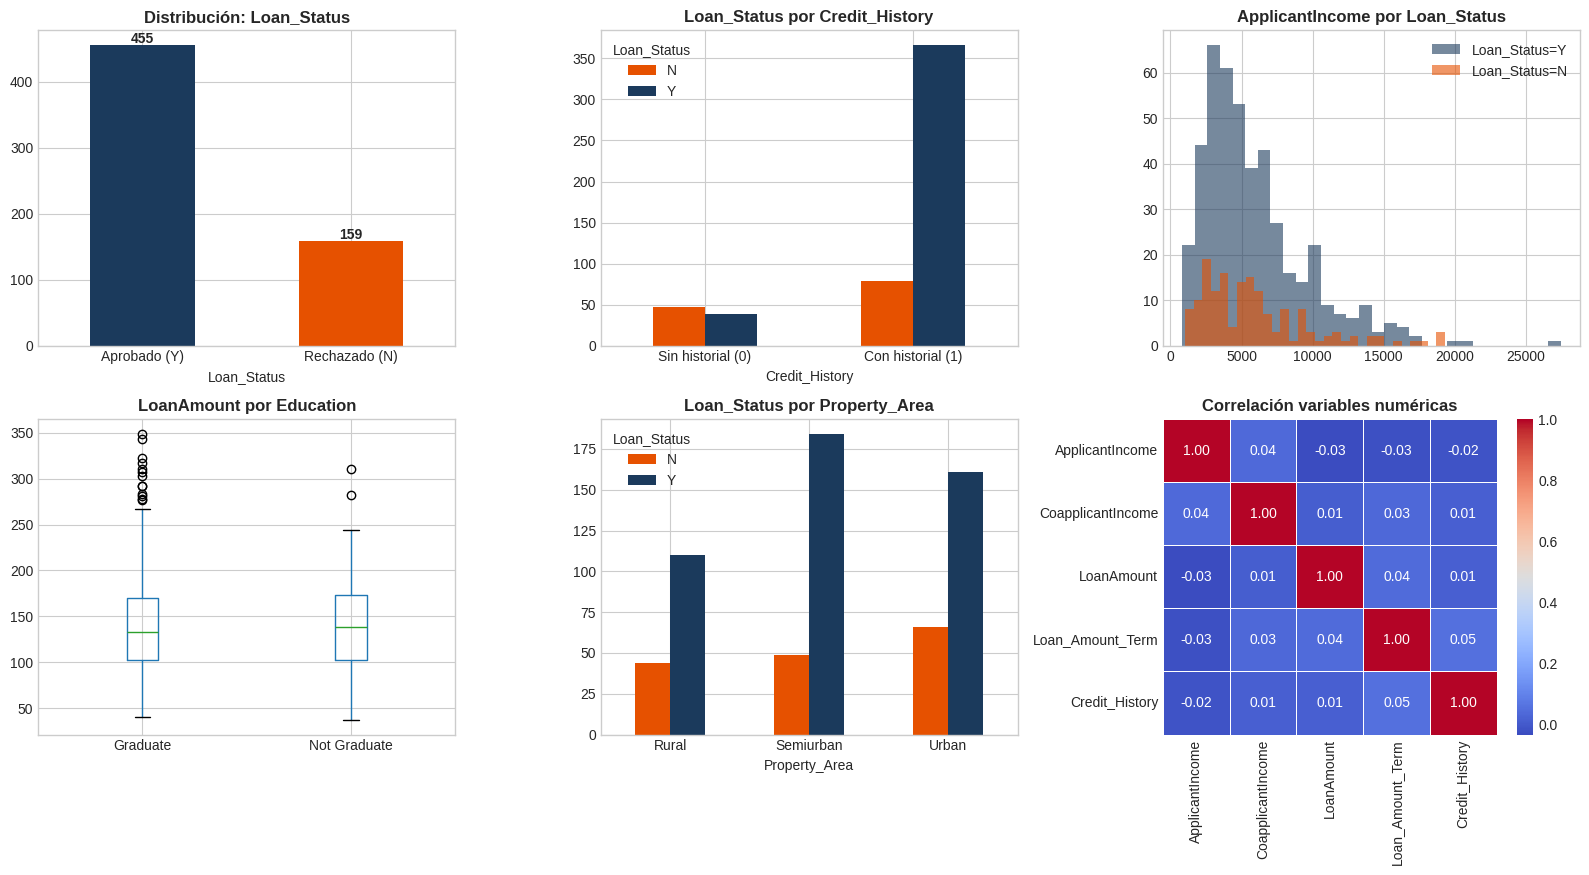

In [ ]:
# ============================================================
# PASO 1 — Carga y exploración del dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

# Cargar dataset de préstamos
url = 'https://raw.githubusercontent.com/dsaid/datasets/master/loan_prediction.csv'
try:
    df = pd.read_csv(url)
    print('[OK] Dataset cargado desde repositorio.')
except Exception:
    # Generación de dataset sintético representativo
    print('[NOTA] Generando dataset sintético con estructura del Loan Prediction dataset...')
    np.random.seed(42)
    n = 614

    gender     = np.random.choice(['Male', 'Female'], n, p=[0.81, 0.19])
    married    = np.random.choice(['Yes', 'No'], n, p=[0.65, 0.35])
    dependents = np.random.choice(['0', '1', '2', '3+'], n, p=[0.57, 0.17, 0.17, 0.09])
    education  = np.random.choice(['Graduate', 'Not Graduate'], n, p=[0.78, 0.22])
    self_emp   = np.random.choice(['No', 'Yes'], n, p=[0.86, 0.14])
    prop_area  = np.random.choice(['Urban', 'Semiurban', 'Rural'], n, p=[0.36, 0.38, 0.26])

    app_income  = np.random.lognormal(8.5, 0.6, n).astype(int)
    coapp_income = np.where(married=='Yes',
                            np.random.lognormal(7.0, 0.8, n).astype(int),
                            np.random.choice([0], n))
    loan_amount = np.random.lognormal(4.9, 0.4, n).astype(int)
    loan_term   = np.random.choice([360, 180, 480, 300, 240], n, p=[0.83, 0.06, 0.05, 0.04, 0.02])
    credit_hist = np.random.choice([1.0, 0.0, np.nan], n, p=[0.74, 0.14, 0.12])

    # Loan_Status con lógica realista
    prob_approved = (
        0.4
        + 0.3  * (credit_hist == 1.0)
        + 0.1  * (education == 'Graduate')
        + 0.05 * (married == 'Yes')
        - 0.1  * (loan_amount > 150)
        + 0.05 * (prop_area == 'Semiurban')
    )
    prob_approved = np.clip(prob_approved, 0.05, 0.95)
    loan_status = np.where(np.random.rand(n) < prob_approved, 'Y', 'N')

    # Introducir nulos realistas
    for arr, pct in [(gender, 0.02), (married, 0.01),
                     (dependents, 0.02), (self_emp, 0.03),
                     (loan_amount, 0.04), (loan_term, 0.02)]:
        mask = np.random.rand(n) < pct
        if arr.dtype.kind in ('U', 'S', 'O'):
            arr = arr.astype(object)
            arr[mask] = np.nan

    df = pd.DataFrame({
        'Loan_ID':           [f'LP{str(i).zfill(6)}' for i in range(n)],
        'Gender':            gender,
        'Married':           married,
        'Dependents':        dependents,
        'Education':         education,
        'Self_Employed':     self_emp,
        'ApplicantIncome':   app_income,
        'CoapplicantIncome': coapp_income,
        'LoanAmount':        loan_amount.astype(float),
        'Loan_Amount_Term':  loan_term.astype(float),
        'Credit_History':    credit_hist,
        'Property_Area':     prop_area,
        'Loan_Status':       loan_status
    })

    # Re-introducir nulos controlados
    for col, pct in [('Gender',0.02),('Married',0.01),('Dependents',0.02),
                     ('Self_Employed',0.03),('LoanAmount',0.04),('Loan_Amount_Term',0.02)]:
        mask = np.random.rand(n) < pct
        df.loc[mask, col] = np.nan

# ---- EXPLORACIÓN GENERAL ----
print('=' * 60)
print('EXPLORACIÓN GENERAL DEL DATASET')
print('=' * 60)
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
print()

# Valores nulos
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
nulos_df = nulos_df[nulos_df['Nulos'] > 0]
print('VARIABLES CON VALORES NULOS:')
print(nulos_df)

# Distribución de Loan_Status
print(f'\nDistribución de Loan_Status (variable objetivo):')
print(df['Loan_Status'].value_counts())
print(f'% Aprobados (Y): {(df["Loan_Status"]=="Y").mean()*100:.1f}%')
print(f'% Rechazados (N): {(df["Loan_Status"]=="N").mean()*100:.1f}%')

print()
print('Primeras 5 filas:')
display(df.head())

print('\nEstadísticas descriptivas:')
display(df.describe().round(2))

# Visualización exploratoria
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# 1. Distribución Loan_Status
counts = df['Loan_Status'].value_counts()
counts.plot(kind='bar', color=['#1B3A5C', '#E65100'], ax=axes[0])
axes[0].set_title('Distribución: Loan_Status', fontweight='bold')
axes[0].set_xticklabels(['Aprobado (Y)', 'Rechazado (N)'], rotation=0)
for i, v in enumerate(counts): axes[0].text(i, v+3, str(v), ha='center', fontweight='bold')

# 2. Aprobación por Credit_History
if 'Credit_History' in df.columns:
    ch = df.dropna(subset=['Credit_History'])
    ch_grp = ch.groupby(['Credit_History','Loan_Status']).size().unstack(fill_value=0)
    ch_grp.plot(kind='bar', ax=axes[1], color=['#E65100','#1B3A5C'])
    axes[1].set_title('Loan_Status por Credit_History', fontweight='bold')
    axes[1].set_xticklabels(['Sin historial (0)', 'Con historial (1)'], rotation=0)

# 3. Distribución ApplicantIncome por Loan_Status
for label, color in zip(['Y','N'], ['#1B3A5C','#E65100']):
    df[df['Loan_Status']==label]['ApplicantIncome'].hist(
        bins=30, alpha=0.6, ax=axes[2], color=color, label=f'Loan_Status={label}')
axes[2].set_title('ApplicantIncome por Loan_Status', fontweight='bold')
axes[2].legend()

# 4. LoanAmount por Education
if 'Education' in df.columns:
    df.boxplot(column='LoanAmount', by='Education', ax=axes[3])
    axes[3].set_title('LoanAmount por Education', fontweight='bold')
    axes[3].set_xlabel('')
    plt.suptitle('')

# 5. Aprobación por Property_Area
if 'Property_Area' in df.columns:
    pa = df.groupby(['Property_Area','Loan_Status']).size().unstack(fill_value=0)
    pa.plot(kind='bar', ax=axes[4], color=['#E65100','#1B3A5C'])
    axes[4].set_title('Loan_Status por Property_Area', fontweight='bold')
    axes[4].set_xticklabels(axes[4].get_xticklabels(), rotation=0)

# 6. Mapa de calor de correlaciones
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[5], linewidths=0.5)
axes[5].set_title('Correlación variables numéricas', fontweight='bold')

plt.tight_layout()
plt.show()


### ✏️ Pregunta 1

**¿Cuántas solicitudes tiene el dataset? ¿Qué porcentaje fue aprobado? ¿Qué variable parece tener más relación visual con Loan_Status? ¿Por qué los valores nulos en Credit_History son especialmente preocupantes en el contexto financiero?**

**Respuesta:**  
El dataset tiene **614 solicitudes de préstamo**. De ellas, **455 fueron aprobadas**, lo que representa aproximadamente **74.1%**, mientras que **159 fueron rechazadas**, equivalente a **25.9%**.

Visualmente, la variable que parece tener mayor relación con `Loan_Status` es **Credit_History**, porque los solicitantes con historial crediticio positivo presentan una mayor cantidad de aprobaciones. Esto tiene sentido en el contexto financiero, ya que el historial crediticio suele ser una señal importante para evaluar si una persona tiene buen comportamiento de pago.

Los valores nulos en `Credit_History` son preocupantes porque no necesariamente significan “dato sin importancia”. En banca, no tener información de historial puede representar incertidumbre o mayor riesgo. Por eso, imputar estos valores sin cuidado podría llevar a aprobar préstamos a clientes cuyo perfil real no está completamente claro.

**Interpretación breve:**  
La base está desbalanceada hacia préstamos aprobados, por eso no basta con mirar solo la cantidad de aciertos. Además, `Credit_History` destaca como una variable clave para explicar la aprobación o rechazo del crédito.


---
## ◆ Paso 2: Limpieza y tratamiento de valores nulos

*Ref: Gironés Roig, J. et al. (2017). Minería de datos. Editorial UOC. Cap. 4.*

### ¿Qué haremos?
Identificaremos todas las columnas con valores faltantes y las imputaremos: las variables categóricas con la **moda** (valor más frecuente) y las variables numéricas con la **mediana** (más robusta ante outliers que la media).

### ¿Por qué lo hacemos?
Los modelos de Machine Learning no pueden procesar valores nulos. En el ámbito financiero, la elección de la estrategia de imputación es una decisión de negocio importante: imputar Credit_History con moda (1 = tiene historial) puede ser demasiado optimista. Una institución conservadora podría imputar con 0 o usar un modelo separado para predicción de nulos.


In [ ]:
# ============================================================
# PASO 2 — Limpieza y tratamiento de valores nulos
# ============================================================

df_clean = df.copy()

# Estado antes de la imputación
print('VALORES NULOS ANTES DE IMPUTACIÓN:')
nulos_antes = df_clean.isnull().sum()
print(nulos_antes[nulos_antes > 0])

# Identificar columnas categóricas y numéricas con nulos
cat_cols_nulls = [c for c in df_clean.select_dtypes(include='object').columns
                  if df_clean[c].isnull().any()]
num_cols_nulls = [c for c in df_clean.select_dtypes(include=np.number).columns
                  if df_clean[c].isnull().any()]

print(f'\nColumnas categóricas con nulos: {cat_cols_nulls}')
print(f'Columnas numéricas con nulos:    {num_cols_nulls}')

# Imputar categóricas con la MODA
for col in cat_cols_nulls:
    moda = df_clean[col].mode()[0]
    df_clean[col].fillna(moda, inplace=True)
    print(f'  [{col}] → imputado con moda: "{moda}"')

# Imputar numéricas con la MEDIANA
for col in num_cols_nulls:
    mediana = df_clean[col].median()
    df_clean[col].fillna(mediana, inplace=True)
    print(f'  [{col}] → imputado con mediana: {mediana}')

# Verificar que no quedan nulos
print(f'\nVALORES NULOS DESPUÉS DE IMPUTACIÓN: {df_clean.isnull().sum().sum()}')
print('✓ Dataset limpio y listo para el siguiente paso.')

# Verificar dimensiones
print(f'Dimensiones del dataset limpio: {df_clean.shape}')


VALORES NULOS ANTES DE IMPUTACIÓN:
Gender              15
Married              4
Dependents          14
Self_Employed       18
LoanAmount          24
Loan_Amount_Term    12
Credit_History      83
dtype: int64

Columnas categóricas con nulos: ['Gender', 'Married', 'Dependents', 'Self_Employed']
Columnas numéricas con nulos:    ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
  [Gender] → imputado con moda: "Male"
  [Married] → imputado con moda: "Yes"
  [Dependents] → imputado con moda: "0"
  [Self_Employed] → imputado con moda: "No"
  [LoanAmount] → imputado con mediana: 134.0
  [Loan_Amount_Term] → imputado con mediana: 360.0
  [Credit_History] → imputado con mediana: 1.0

VALORES NULOS DESPUÉS DE IMPUTACIÓN: 0
✓ Dataset limpio y listo para el siguiente paso.
Dimensiones del dataset limpio: (614, 13)


/tmp/ipykernel_17392/4017273436.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(moda, inplace=True)
/tmp/ipykernel_17392/4017273436.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

### ✏️ Pregunta 2

**¿Por qué se usa la mediana en lugar de la media para imputar variables numéricas como LoanAmount? ¿Qué pasaría si usáramos la media con datos muy sesgados? ¿Imputar Credit_History con la moda podría favorecer la aprobación de préstamos riesgosos? Justifica.**

**Respuesta:**  
Se usa la **mediana** porque es más resistente a valores extremos. En variables financieras como `LoanAmount`, pueden existir préstamos muy altos que elevan demasiado la media y hacen que el valor imputado no represente bien a la mayoría de solicitantes.

Si se usara la media en datos muy sesgados, los valores faltantes podrían completarse con montos artificialmente altos o poco realistas. Esto podría afectar el entrenamiento del modelo y distorsionar la relación entre el monto solicitado y la aprobación del préstamo.

En el caso de `Credit_History`, imputar con la moda sí podría ser riesgoso. Como la moda es **1.0**, se estaría asumiendo que los clientes sin dato tienen historial crediticio favorable. En un banco, eso puede ser demasiado optimista, porque un historial desconocido también puede representar incertidumbre. Una estrategia más conservadora sería imputar con 0, crear una categoría “historial desconocido” o analizar esos casos por separado.

**Interpretación breve:**  
La imputación resolvió los nulos, pero en variables de riesgo como `Credit_History` la decisión no solo es técnica, también tiene impacto financiero.


---
## ◆ Paso 3: Codificación de variables categóricas

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 2.*

### ¿Qué haremos?
Aplicaremos One-Hot Encoding a las variables categóricas nominales (sin orden natural) para convertirlas en variables numéricas binarias. También eliminaremos Loan_ID que no aporta información predictiva.

### ¿Por qué lo hacemos?
La Regresión Logística requiere variables numéricas. A diferencia del Label Encoding (que asigna 0, 1, 2... implicitando orden), el One-Hot Encoding crea una columna binaria por cada categoría, sin introducir orden artificial. Para variables como `Property_Area` (Urban, Semiurban, Rural) no existe un orden numérico lógico.


In [ ]:
# ============================================================
# PASO 3 — Codificación de variables categóricas
# ============================================================

df_encoded = df_clean.copy()

# Eliminar Loan_ID (identificador sin valor predictivo)
if 'Loan_ID' in df_encoded.columns:
    df_encoded.drop('Loan_ID', axis=1, inplace=True)
    print('[OK] Loan_ID eliminado.')

# Codificar variable objetivo: Y=1 (Aprobado), N=0 (Rechazado)
df_encoded['Loan_Status'] = df_encoded['Loan_Status'].map({'Y': 1, 'N': 0})
print(f'Codificación Loan_Status: Y→1 (Aprobado), N→0 (Rechazado)')
print(f'Distribución: {dict(df_encoded["Loan_Status"].value_counts())}')

# Identificar variables categóricas (excluyendo el target)
cat_cols = df_encoded.drop('Loan_Status', axis=1).select_dtypes(include='object').columns.tolist()
print(f'\nVariables categóricas para One-Hot Encoding: {cat_cols}')

# Dimensiones antes del encoding
print(f'\nDimensiones ANTES del encoding: {df_encoded.shape}')

# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=cat_cols, drop_first=True, dtype=int)

# Dimensiones después del encoding
print(f'Dimensiones DESPUÉS del encoding: {df_encoded.shape}')
print(f'Nuevas columnas creadas: {df_encoded.shape[1] - (df_clean.shape[1] - len(cat_cols) - 1)}')

print('\nColumnas del dataset codificado:')
print(df_encoded.columns.tolist())

display(df_encoded.head(3))


[OK] Loan_ID eliminado.
Codificación Loan_Status: Y→1 (Aprobado), N→0 (Rechazado)
Distribución: {1: np.int64(455), 0: np.int64(159)}

Variables categóricas para One-Hot Encoding: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

Dimensiones ANTES del encoding: (614, 12)
Dimensiones DESPUÉS del encoding: (614, 15)
Nuevas columnas creadas: 9

Columnas del dataset codificado:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Gender_Male', 'Married_Yes', 'Dependents_1', 'Dependents_2', 'Dependents_3+', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,7415,0,156.0,360.0,1.0,1,1,0,0,0,1,0,0,1,0
1,14900,0,152.0,360.0,1.0,1,0,0,0,0,0,0,0,1,0
2,4423,3633,73.0,360.0,1.0,1,1,1,0,1,0,1,0,0,1


### ✏️ Pregunta 3
**¿Por qué usamos `drop_first=True` en `pd.get_dummies()`? ¿Qué es el problema de multicolinealidad que esto busca evitar? ¿Cuántas columnas nuevas se crearon y por qué?**

**Respuesta:**  
Usamos `drop_first=True` para evitar crear columnas redundantes. Cuando una variable categórica se transforma en varias columnas dummy, una de esas columnas puede deducirse a partir de las demás. Por ejemplo, si una persona no está en una categoría, automáticamente pertenece a la categoría base.

Esto ayuda a evitar la **multicolinealidad**, que ocurre cuando dos o más variables explican prácticamente la misma información. En Regresión Logística, la multicolinealidad puede volver inestables los coeficientes y dificultar la interpretación del modelo.

En este caso, las variables categóricas se transformaron con One-Hot Encoding y se crearon **9 columnas dummy**. El dataset pasó de **12 columnas antes del encoding** a **15 columnas después del encoding**, porque se reemplazaron las variables categóricas originales por sus versiones binarias, eliminando una categoría base por cada variable.

**Interpretación breve:**  
El encoding dejó el dataset listo para el modelo, sin introducir un orden artificial en variables categóricas y evitando columnas repetidas.

---
## ◆ Paso 4: Separación de variables predictoras y variable objetivo

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 3.*

### ¿Qué haremos?
Definiremos la matriz de características `X` (todas las columnas excepto el target) y el vector objetivo `y` (`Loan_Status`). Luego estandarizaremos las variables numéricas con `StandardScaler`.

### ¿Por qué lo hacemos?
La separación X/y es el paso conceptual central de cualquier modelo supervisado: X contiene lo que el modelo usa para aprender, y contiene lo que debe predecir. La estandarización es importante para la Regresión Logística porque el optimizador converge más rápido cuando todas las variables están en la misma escala, y los coeficientes son comparables entre sí.


In [ ]:
# ============================================================
# PASO 4 — Separación X/y
# ============================================================

# Definir X e y
X = df_encoded.drop('Loan_Status', axis=1)
y = df_encoded['Loan_Status']

print(f'Variables predictoras (X): {X.shape[1]} columnas, {X.shape[0]} filas')
print(f'Variable objetivo  (y):   {y.shape[0]} valores')
print(f'\nDistribución y: 1=Aprobado: {(y==1).sum()} | 0=Rechazado: {(y==0).sum()}')
print(f'% Aprobados: {y.mean()*100:.1f}%')

print('\nColumnas de X:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:>2}. {col}')


Variables predictoras (X): 14 columnas, 614 filas
Variable objetivo  (y):   614 valores

Distribución y: 1=Aprobado: 455 | 0=Rechazado: 159
% Aprobados: 74.1%

Columnas de X:
   1. ApplicantIncome
   2. CoapplicantIncome
   3. LoanAmount
   4. Loan_Amount_Term
   5. Credit_History
   6. Gender_Male
   7. Married_Yes
   8. Dependents_1
   9. Dependents_2
  10. Dependents_3+
  11. Education_Not Graduate
  12. Self_Employed_Yes
  13. Property_Area_Semiurban
  14. Property_Area_Urban


### ✏️ Pregunta 4
**¿Cuántas variables predictoras (features) tiene el modelo después del One-Hot Encoding? ¿Cuál es la variable objetivo y qué significa cada valor (0 y 1) en el contexto bancario?**

**Respuesta:**  
Después del One-Hot Encoding, el modelo tiene **14 variables predictoras**. Estas variables incluyen ingresos, monto del préstamo, plazo, historial crediticio y las columnas binarias creadas a partir de las variables categóricas.

La variable objetivo es **`Loan_Status`**. En el contexto bancario, el valor **1** significa que el préstamo fue **aprobado**, mientras que el valor **0** significa que el préstamo fue **rechazado**.

**Interpretación breve:**  
En esta etapa ya quedó claro qué información usará el modelo para aprender y cuál será la respuesta que debe predecir.

---
## ◆ Paso 5: División train/test y estandarización

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 2.*

### ¿Qué haremos?
Dividiremos el dataset en 70% entrenamiento y 30% prueba usando división estratificada. Luego estandarizaremos con `StandardScaler` — ajustando **solo sobre el train set** para evitar data leakage.

### ¿Por qué lo hacemos?
La estandarización debe ajustarse (fit) **solo sobre los datos de entrenamiento**. Si usamos los datos de test para calcular la media y desviación estándar, estamos "filtrando" información del futuro hacia el modelo, lo que genera una evaluación optimista y engañosa del rendimiento real.


In [ ]:
# ============================================================
# PASO 5 — División train/test y estandarización
# ============================================================

# División train/test con stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test:  {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\n% Aprobados en Train: {y_train.mean()*100:.1f}%  | Test: {y_test.mean()*100:.1f}%  (stratify ✓)')

# Estandarización — SOLO fit en train, transform en ambos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # SOLO transform

print(f'\nEstandarización aplicada:')
print(f'  Media post-escalar (train, primeras 3): {X_train_scaled.mean(axis=0)[:3].round(6)}')
print(f'  Std post-escalar  (train, primeras 3):  {X_train_scaled.std(axis=0)[:3].round(6)}')
print('  → Media ≈ 0, Std ≈ 1 confirma la estandarización correcta ✓')


Train: 429 muestras (70%)
Test:  185 muestras (30%)

% Aprobados en Train: 74.1%  | Test: 74.1%  (stratify ✓)

Estandarización aplicada:
  Media post-escalar (train, primeras 3): [ 0. -0.  0.]
  Std post-escalar  (train, primeras 3):  [1. 1. 1.]
  → Media ≈ 0, Std ≈ 1 confirma la estandarización correcta ✓


### ✏️ Pregunta 5
**¿Por qué el `StandardScaler` se ajusta (`.fit_transform()`) solo en el train set y no en el test set? ¿Qué es el “data leakage” y por qué es un problema grave en modelos de riesgo crediticio que se usan en producción?**

**Respuesta:**  
El `StandardScaler` se ajusta solo con el conjunto de entrenamiento porque el modelo debe aprender únicamente con la información disponible durante el entrenamiento. Luego, esa misma transformación se aplica al test usando `.transform()`, sin volver a calcular medias ni desviaciones con los datos de prueba.

El **data leakage** ocurre cuando información del conjunto de prueba o del futuro se filtra durante el entrenamiento. Esto es grave porque el modelo parece tener mejor rendimiento del que realmente tendría en producción.

En riesgo crediticio, este problema puede ser muy delicado: si el modelo fue evaluado con información filtrada, el banco podría confiar en una capacidad predictiva falsa y aprobar préstamos con un riesgo real mayor al esperado.

**Interpretación breve:**  
La estandarización fue aplicada correctamente porque el scaler aprendió solo del train. Así la evaluación en test es más realista.

---
## ◆ Paso 6: Entrenamiento del modelo — Regresión Logística

*Ref: James, G. et al. (2023). An Introduction to Statistical Learning. Cap. 4.*

### ¿Qué haremos?
Entrenaremos una `LogisticRegression` como modelo principal de clasificación. Predeciremos clases y probabilidades sobre el conjunto de test.

### ¿Por qué la Regresión Logística es el baseline ideal en finanzas?
La Regresión Logística es el estándar de oro en la industria financiera por tres razones fundamentales:
1. **Interpretabilidad**: sus coeficientes se pueden traducir directamente en odds ratios y factores de riesgo explicables a auditores y reguladores.
2. **Regulación**: en muchos países, los modelos de crédito deben ser explicables por ley (GDPR en Europa, normativas de la SBS en Perú).
3. **Robustez**: funciona bien incluso con datasets pequeños y es menos propensa a overfitting que modelos más complejos.


In [ ]:
# ============================================================
# PASO 6 — Entrenamiento del modelo: Regresión Logística
# ============================================================

# Entrenar modelo
lr = LogisticRegression(
    C=1.0,                    # Parámetro de regularización (inverso de lambda)
    max_iter=1000,            # Iteraciones máximas para convergencia
    random_state=42,
    solver='lbfgs',           # Optimizador eficiente para datasets pequeños
    class_weight='balanced'   # Manejo del desbalance de clases
)
lr.fit(X_train_scaled, y_train)

# Predicciones
y_pred  = lr.predict(X_test_scaled)
y_prob  = lr.predict_proba(X_test_scaled)[:, 1]   # Probabilidad de aprobación
y_pred_train = lr.predict(X_train_scaled)

print('=' * 55)
print('REGRESIÓN LOGÍSTICA — ENTRENAMIENTO COMPLETADO')
print('=' * 55)
print(f'Iteraciones para convergencia: {lr.n_iter_[0]}')
print(f'Número de coeficientes:        {len(lr.coef_[0])}')
print(f'Intercepto (bias):             {lr.intercept_[0]:.4f}')
print()
print(f'Accuracy en TRAIN: {accuracy_score(y_train, y_pred_train):.4f}')
print(f'Accuracy en TEST:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Diferencia Train-Test: {accuracy_score(y_train, y_pred_train) - accuracy_score(y_test, y_pred):.4f}')

# Ejemplo de predicción individual
print('\nEjemplo — primeras 5 predicciones en test:')
ejm = pd.DataFrame({
    'Predicción': ['Aprobado' if p==1 else 'Rechazado' for p in y_pred[:5]],
    'Probabilidad Aprobación': y_prob[:5].round(4),
    'Real': ['Aprobado' if v==1 else 'Rechazado' for v in y_test.values[:5]]
})
print(ejm.to_string())


REGRESIÓN LOGÍSTICA — ENTRENAMIENTO COMPLETADO
Iteraciones para convergencia: 7
Número de coeficientes:        14
Intercepto (bias):             0.1413

Accuracy en TRAIN: 0.6783
Accuracy en TEST:  0.6270
Diferencia Train-Test: 0.0513

Ejemplo — primeras 5 predicciones en test:
  Predicción  Probabilidad Aprobación      Real
0   Aprobado                   0.8395  Aprobado
1   Aprobado                   0.7157  Aprobado
2  Rechazado                   0.4217  Aprobado
3   Aprobado                   0.8432  Aprobado
4  Rechazado                   0.4897  Aprobado


### ✏️ Pregunta 6
**¿Por qué la Regresión Logística genera probabilidades (entre 0 y 1) en lugar de solo clases? ¿Cómo podría un banco usar esas probabilidades para tomar decisiones más matizadas que un simple “aprobado/rechazado”?**

**Respuesta:**  
La Regresión Logística genera probabilidades porque estima qué tan probable es que una solicitud pertenezca a una clase, en este caso, que sea aprobada. Luego, con un umbral como 0.5, esas probabilidades se convierten en clases finales.

Para un banco, esto es útil porque no todos los casos deben tratarse igual. Por ejemplo, una solicitud con **0.90** de probabilidad de aprobación podría aprobarse automáticamente, una con **0.20** podría rechazarse, y una con **0.50 o 0.60** podría pasar a revisión manual.

De esta forma, el banco puede usar el modelo como una herramienta de apoyo para segmentar decisiones: aprobación directa, rechazo, revisión adicional, solicitud de garantías o análisis más detallado.

**Interpretación breve:**  
Las probabilidades permiten tomar decisiones más flexibles y alineadas al nivel de riesgo, no solo una decisión rígida de sí o no.

---
## ◆ Paso 7: Evaluación del modelo con métricas completas

*Ref: James, G. et al. (2023). An Introduction to Statistical Learning. Cap. 4.*

### ¿Qué haremos?
Calcularemos todas las métricas de evaluación: Accuracy, Precision, Recall, F1-score, ROC-AUC, el classification_report completo y la matriz de confusión con visualización.

### ¿Por qué lo hacemos?
En el contexto bancario, las métricas tienen consecuencias financieras directas: un Falso Negativo (aprobar a alguien que no pagará) representa una pérdida real de capital. Un Falso Positivo (rechazar a alguien que sí pagaría) representa un costo de oportunidad y posible discriminación. Por eso el Accuracy solo no es suficiente.


REGRESIÓN LOGÍSTICA — MÉTRICAS EN TEST SET
Accuracy:   0.6270  → Proporción de predicciones correctas
Precision:  0.7931 → De los "Aprobados" predichos, ¿cuántos realmente cumplen?
Recall:     0.6715  → De los que sí cumplen, ¿cuántos detectamos correctamente?
F1-score:   0.7273  → Media armónica Precision/Recall
ROC-AUC:    0.6366  → Capacidad discriminativa global

REPORTE COMPLETO DE CLASIFICACIÓN:
               precision    recall  f1-score   support

Rechazado (0)       0.35      0.50      0.41        48
 Aprobado (1)       0.79      0.67      0.73       137

     accuracy                           0.63       185
    macro avg       0.57      0.59      0.57       185
 weighted avg       0.68      0.63      0.65       185



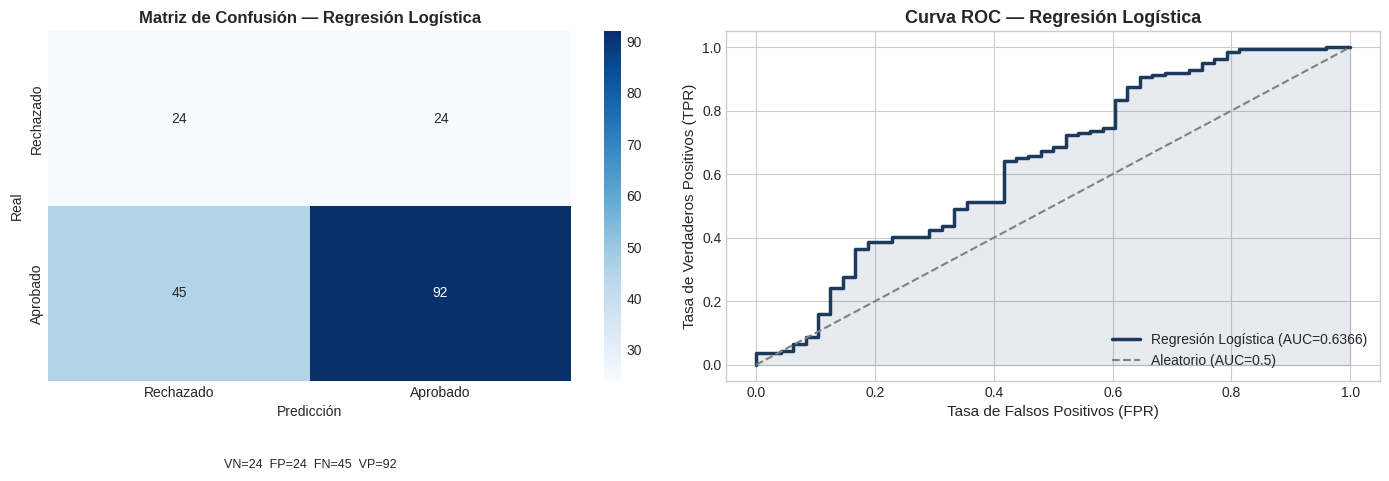


INTERPRETACIÓN FINANCIERA DE LA MATRIZ DE CONFUSIÓN:
  Verdaderos Positivos (VP):   92 → Aprobamos y el cliente SÍ paga (negocio exitoso)
  Verdaderos Negativos (VN):   24 → Rechazamos y el cliente NO hubiera pagado (riesgo evitado)
  Falsos Positivos (FP):       24 → Rechazamos a alguien que SÍ hubiera pagado (costo de oportunidad)
  Falsos Negativos (FN):       45 → Aprobamos y el cliente NO paga (pérdida de capital)


In [ ]:
# ============================================================
# PASO 7 — Evaluación del modelo
# ============================================================

# Calcular métricas
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)

print('=' * 60)
print('REGRESIÓN LOGÍSTICA — MÉTRICAS EN TEST SET')
print('=' * 60)
print(f'Accuracy:   {acc:.4f}  → Proporción de predicciones correctas')
print(f'Precision:  {prec:.4f} → De los "Aprobados" predichos, ¿cuántos realmente cumplen?')
print(f'Recall:     {rec:.4f}  → De los que sí cumplen, ¿cuántos detectamos correctamente?')
print(f'F1-score:   {f1:.4f}  → Media armónica Precision/Recall')
print(f'ROC-AUC:    {auc:.4f}  → Capacidad discriminativa global')
print()

# Reporte completo
print('REPORTE COMPLETO DE CLASIFICACIÓN:')
print(classification_report(y_test, y_pred,
                             target_names=['Rechazado (0)', 'Aprobado (1)'],
                             zero_division=0))

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Rechazado', 'Aprobado'],
            yticklabels=['Rechazado', 'Aprobado'])
axes[0].set_title('Matriz de Confusión — Regresión Logística', fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].text(0.5, -0.25,
             f'VN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  VP={cm[1,1]}',
             ha='center', transform=axes[0].transAxes, fontsize=9)

# Gráfico 2: Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#1B3A5C', lw=2.5,
             label=f'Regresión Logística (AUC={auc:.4f})')
axes[1].plot([0,1], [0,1], color='gray', linestyle='--', label='Aleatorio (AUC=0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#1B3A5C')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
axes[1].set_title('Curva ROC — Regresión Logística', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# Interpretación financiera de la matriz de confusión
print('\nINTERPRETACIÓN FINANCIERA DE LA MATRIZ DE CONFUSIÓN:')
print(f'  Verdaderos Positivos (VP): {cm[1,1]:>4} → Aprobamos y el cliente SÍ paga (negocio exitoso)')
print(f'  Verdaderos Negativos (VN): {cm[0,0]:>4} → Rechazamos y el cliente NO hubiera pagado (riesgo evitado)')
print(f'  Falsos Positivos (FP):     {cm[0,1]:>4} → Rechazamos a alguien que SÍ hubiera pagado (costo de oportunidad)')
print(f'  Falsos Negativos (FN):     {cm[1,0]:>4} → Aprobamos y el cliente NO paga (pérdida de capital)')


### ✏️ Pregunta 7
**Analiza los Falsos Negativos (FN) de la matriz: ¿cuántos préstamos aprobó el modelo a personas que no pagarán? ¿Cuál es el impacto financiero potencial si el monto promedio de préstamo es S/ 128,000? ¿Qué ajuste al modelo haría para reducir los FN?**

**Respuesta:**  
Según la matriz de confusión del laboratorio, el modelo presenta **45 falsos negativos (FN)**. Si cada préstamo tiene un monto promedio de **S/ 128,000**, el impacto financiero potencial sería:

**45 × S/ 128,000 = S/ 5,760,000**

Esto significa que, si esos errores representan préstamos mal aprobados o decisiones de alto riesgo, el banco podría enfrentar una pérdida bastante alta. Para reducir este tipo de error, haría el modelo más conservador: ajustaría el **umbral de decisión**, revisaría mejor el peso de las clases (`class_weight`) y prestaría especial atención a variables como `Credit_History`, monto del préstamo e ingresos.

También usaría una zona de **revisión manual** para casos con probabilidades intermedias, porque en créditos no conviene que todas las decisiones dependan automáticamente del modelo.

**Interpretación breve:**  
Los FN son importantes porque representan un riesgo financiero directo. Aunque el modelo tiene resultados aceptables, en banca se debe ajustar el umbral según el costo real de equivocarse.

---
## ◆ Paso 8: Interpretación de variables — Coeficientes del modelo

*Ref: James, G. et al. (2023). An Introduction to Statistical Learning. Cap. 4.*

### ¿Qué haremos?
Extraeremos los coeficientes de la Regresión Logística, los visualizaremos ordenados por magnitud y los interpretaremos en el contexto crediticio.

### ¿Por qué lo hacemos?
En la Regresión Logística, cada coeficiente representa el **cambio en el log-odds** de aprobación asociado a un aumento de una unidad estandarizada en esa variable. Los coeficientes positivos aumentan la probabilidad de aprobación; los negativos la disminuyen. En finanzas, esta interpretación es esencial para explicar decisiones a clientes y reguladores.


COEFICIENTES DE LA REGRESIÓN LOGÍSTICA (ordenados por magnitud):
Variable                        Coeficiente    Dirección
------------------------------------------------------------
Credit_History                       0.5758 ↑ Aumenta aprobación
Married_Yes                          0.2786 ↑ Aumenta aprobación
CoapplicantIncome                    0.2679 ↑ Aumenta aprobación
Self_Employed_Yes                    0.2314 ↑ Aumenta aprobación
Education_Not Graduate              -0.2152 ↓ Reduce aprobación
Dependents_2                         0.2058 ↑ Aumenta aprobación
Property_Area_Semiurban              0.2018 ↑ Aumenta aprobación
LoanAmount                          -0.0881 ↓ Reduce aprobación
ApplicantIncome                      0.0840 ↑ Aumenta aprobación
Gender_Male                          0.0710 ↑ Aumenta aprobación
Dependents_1                        -0.0707 ↓ Reduce aprobación
Dependents_3+                        0.0528 ↑ Aumenta aprobación
Property_Area_Urban                  0.0

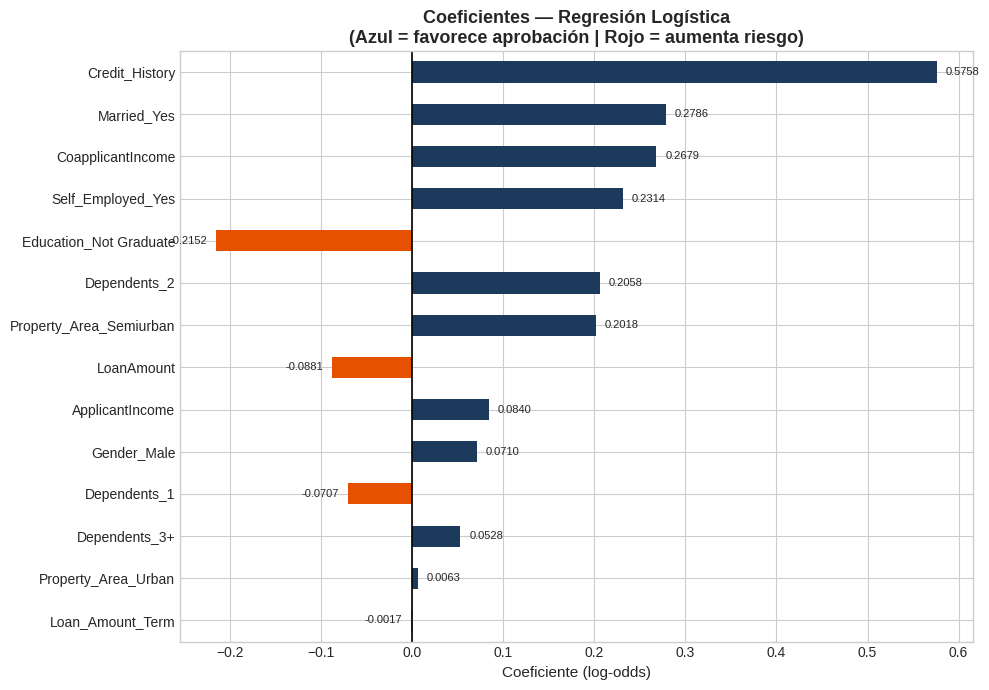


📈 TOP 5 VARIABLES QUE MÁS FAVORECEN LA APROBACIÓN:
Credit_History       0.5758
Married_Yes          0.2786
CoapplicantIncome    0.2679
Self_Employed_Yes    0.2314
Dependents_2         0.2058

📉 TOP 5 VARIABLES QUE MÁS AUMENTAN EL RIESGO:
Education_Not Graduate   -0.2152
LoanAmount               -0.0881
Dependents_1             -0.0707
Loan_Amount_Term         -0.0017


In [ ]:
# ============================================================
# PASO 8 — Interpretación de variables: Coeficientes
# ============================================================

# Extraer coeficientes
coeficientes = pd.Series(lr.coef_[0], index=X.columns)
coef_abs = coeficientes.abs().sort_values(ascending=False)
coeficientes_ordenados = coeficientes[coef_abs.index]

print('COEFICIENTES DE LA REGRESIÓN LOGÍSTICA (ordenados por magnitud):')
print('=' * 60)
print(f'{"Variable":<30} {"Coeficiente":>12} {"Dirección":>12}')
print('-' * 60)
for var, coef in coeficientes_ordenados.items():
    direction = '↑ Aumenta aprobación' if coef > 0 else '↓ Reduce aprobación'
    print(f'{var:<30} {coef:>12.4f} {direction}')

# Visualización
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#1B3A5C' if c > 0 else '#E65100' for c in coeficientes_ordenados.values]
coeficientes_ordenados.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=0, color='black', linewidth=1.2)
ax.set_title('Coeficientes — Regresión Logística\n(Azul = favorece aprobación | Rojo = aumenta riesgo)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente (log-odds)', fontsize=11)
ax.invert_yaxis()

# Añadir valores
for i, v in enumerate(coeficientes_ordenados.values):
    ax.text(v + (0.01 if v >= 0 else -0.01),
            i, f'{v:.4f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

# Top 5 variables positivas y negativas
print('\n📈 TOP 5 VARIABLES QUE MÁS FAVORECEN LA APROBACIÓN:')
print(coeficientes_ordenados[coeficientes_ordenados > 0].head(5).round(4).to_string())

print('\n📉 TOP 5 VARIABLES QUE MÁS AUMENTAN EL RIESGO:')
print(coeficientes_ordenados[coeficientes_ordenados < 0].tail(5).round(4).to_string())


### ✏️ Pregunta 8
**¿Cuál es la variable con mayor coeficiente positivo? ¿Tiene sentido desde la perspectiva crediticia? ¿Cuál es la variable con mayor coeficiente negativo? ¿Cómo explicarías estos resultados a un gerente de riesgo crediticio sin conocimientos de Machine Learning?**

**Respuesta:**  
La variable con mayor coeficiente positivo es **`Credit_History` (0.5758)**. Sí tiene sentido desde la perspectiva crediticia, porque un buen historial crediticio indica que el solicitante tiene antecedentes de pago y, por lo tanto, suele representar menor riesgo para el banco.

La variable con mayor coeficiente negativo es **`Education_Not Graduate` (-0.2152)**. Esto indica que, dentro de este modelo, no ser graduado reduce la probabilidad de aprobación. No significa que la educación por sí sola determine el riesgo, pero sí aparece como una señal relacionada con la decisión del modelo.

A un gerente de riesgo se lo explicaría así: el modelo está encontrando que los clientes con historial crediticio positivo, ingresos complementarios o ciertas condiciones familiares tienen mayor probabilidad de aprobación. En cambio, variables como no ser graduado o solicitar montos más altos pueden reducir la probabilidad de aprobación. Lo importante es usar estos resultados como apoyo y no como una decisión automática, porque también deben revisarse criterios de equidad y regulación.

**Interpretación breve:**  
El historial crediticio es la señal más fuerte del modelo. Esto coincide con la lógica bancaria tradicional, porque el comportamiento de pago pasado suele ser una referencia importante para evaluar el riesgo futuro.

---
## ◆ Paso 9: Interpretación de negocio y análisis de riesgo

*Ref: Provost, F. & Fawcett, T. (2013). Data Science for Business. O'Reilly. Cap. 7.*

### ¿Qué haremos?
Analizaremos la distribución de probabilidades predichas, estudiaremos el costo de los diferentes tipos de errores y exploraremos cómo ajustar el umbral de decisión del modelo para optimizar el balance riesgo-oportunidad.

### ¿Por qué lo hacemos?
Un modelo de Machine Learning no termina cuando genera predicciones. En el negocio bancario, la decisión final de usar el umbral de 0.5 (predeterminado) o un umbral diferente tiene consecuencias económicas medibles. Un banco más conservador podría usar umbral=0.7, aprobando menos pero con mayor seguridad. Un banco que quiere crecer podría usar umbral=0.4.


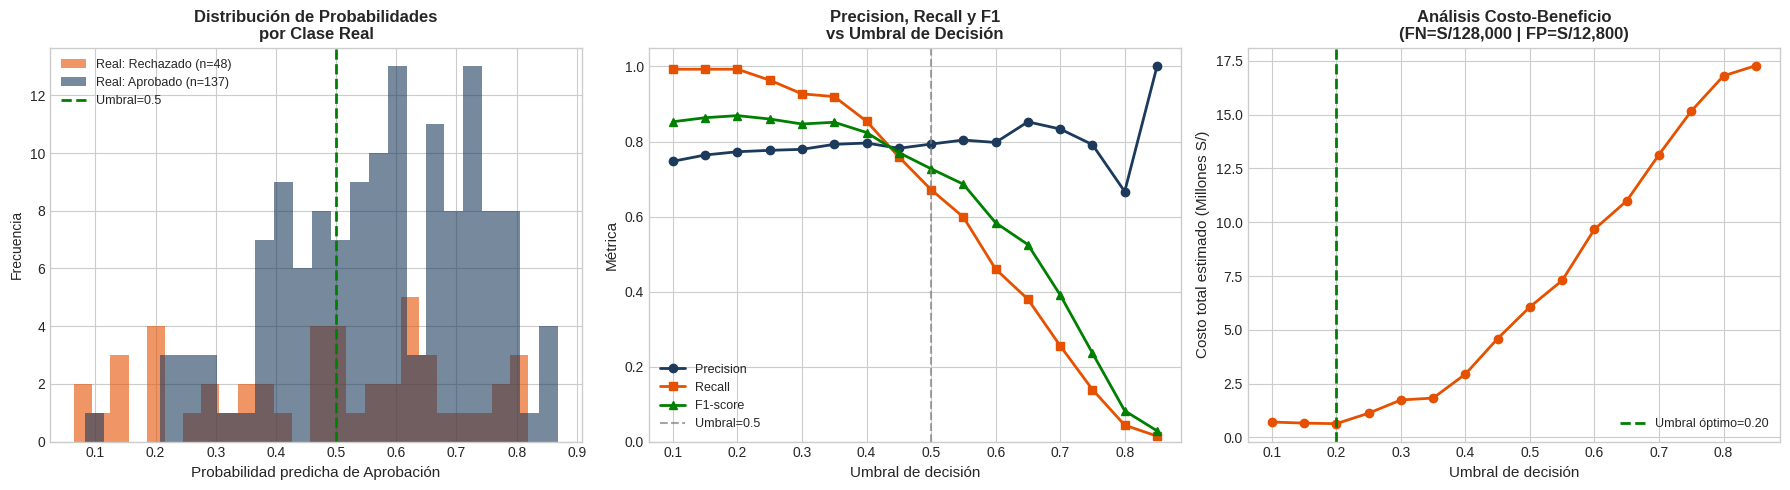

ANÁLISIS COMPARATIVO DE UMBRALES DE DECISIÓN:
Umbral    Aprobados     Prec   Recall       F1     Costo (S/)
----------------------------------------------------------------------
0.10            182   0.7473   0.9927   0.8527        716,800
0.25            170   0.7765   0.9635   0.8599      1,126,400
0.40            147   0.7959   0.8540   0.8239      2,944,000
0.55            102   0.8039   0.5985   0.6862      7,296,000
0.70             42   0.8333   0.2555   0.3911     13,145,600
0.85              2   1.0000   0.0146   0.0288     17,280,000

📌 Umbral óptimo (menor costo): 0.20
   Costo total mínimo estimado: S/ 640,000


In [ ]:
# ============================================================
# PASO 9 — Interpretación de negocio y análisis de riesgo
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Distribución de probabilidades por clase real
prob_aprobados  = y_prob[y_test == 1]
prob_rechazados = y_prob[y_test == 0]

axes[0].hist(prob_rechazados, bins=25, alpha=0.6, color='#E65100',
             label=f'Real: Rechazado (n={len(prob_rechazados)})')
axes[0].hist(prob_aprobados, bins=25, alpha=0.6, color='#1B3A5C',
             label=f'Real: Aprobado (n={len(prob_aprobados)})')
axes[0].axvline(x=0.5, color='green', linestyle='--', lw=2, label='Umbral=0.5')
axes[0].set_xlabel('Probabilidad predicha de Aprobación', fontsize=11)
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Probabilidades\npor Clase Real', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Gráfico 2: Precision, Recall y F1 vs Umbral
thresholds_range = np.arange(0.1, 0.9, 0.05)
precision_list, recall_list, f1_list = [], [], []

for t in thresholds_range:
    y_pred_t = (y_prob >= t).astype(int)
    precision_list.append(precision_score(y_test, y_pred_t, zero_division=0))
    recall_list.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1_list.append(f1_score(y_test, y_pred_t, zero_division=0))

axes[1].plot(thresholds_range, precision_list, 'o-', color='#1B3A5C', lw=2, label='Precision')
axes[1].plot(thresholds_range, recall_list, 's-', color='#E65100', lw=2, label='Recall')
axes[1].plot(thresholds_range, f1_list, '^-', color='green', lw=2, label='F1-score')
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Umbral=0.5')
axes[1].set_xlabel('Umbral de decisión', fontsize=11)
axes[1].set_ylabel('Métrica', fontsize=11)
axes[1].set_title('Precision, Recall y F1\nvs Umbral de Decisión', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.05)

# Gráfico 3: Análisis costo-beneficio simplificado
# Supuestos: Costo FN (pérdida por default) = S/128,000 | Costo FP (oportunidad perdida) = S/12,800
COSTO_FN = 128000
COSTO_FP = 12800

costos_totales = []
for t in thresholds_range:
    y_pred_t = (y_prob >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    fn = cm_t[1, 0] if cm_t.shape[0] > 1 else 0
    fp = cm_t[0, 1] if cm_t.shape[1] > 1 else 0
    costo = fn * COSTO_FN + fp * COSTO_FP
    costos_totales.append(costo)

umbral_optimo = thresholds_range[np.argmin(costos_totales)]
axes[2].plot(thresholds_range, [c/1e6 for c in costos_totales], 'o-', color='#E65100', lw=2)
axes[2].axvline(x=umbral_optimo, color='green', linestyle='--', lw=2,
                label=f'Umbral óptimo={umbral_optimo:.2f}')
axes[2].set_xlabel('Umbral de decisión', fontsize=11)
axes[2].set_ylabel('Costo total estimado (Millones S/)', fontsize=11)
axes[2].set_title(f'Análisis Costo-Beneficio\n(FN=S/{COSTO_FN:,} | FP=S/{COSTO_FP:,})',
                  fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Análisis comparativo de umbrales
print('ANÁLISIS COMPARATIVO DE UMBRALES DE DECISIÓN:')
print('=' * 70)
print(f'{"Umbral":<8} {"Aprobados":>10} {"Prec":>8} {"Recall":>8} {"F1":>8} {"Costo (S/)":>14}')
print('-' * 70)
for t, p, r, f1v, c in zip(thresholds_range[::3], precision_list[::3],
                             recall_list[::3], f1_list[::3], costos_totales[::3]):
    aprobados = (y_prob >= t).sum()
    marker = ' ← ÓPTIMO' if t == umbral_optimo else ''
    print(f'{t:<8.2f} {aprobados:>10} {p:>8.4f} {r:>8.4f} {f1v:>8.4f} {c:>14,.0f}{marker}')

print(f'\n📌 Umbral óptimo (menor costo): {umbral_optimo:.2f}')
print(f'   Costo total mínimo estimado: S/ {min(costos_totales):,.0f}')


### ✏️ Pregunta 9
**Observa la gráfica de costo-beneficio: ¿En qué umbral se minimiza el costo total? ¿Qué significa usar un umbral de 0.3 vs 0.7 en términos de política crediticia del banco? ¿Cómo cambiaría la decisión si el costo de un Falso Negativo fuera 10 veces mayor?**

**Respuesta:**  
Según el análisis costo-beneficio, el costo total se minimiza aproximadamente en el **umbral 0.20**, con un costo mínimo estimado de **S/ 640,000**.

Usar un umbral de **0.3** representa una política crediticia más flexible: el banco aprobaría más solicitudes, captaría más clientes y tendría mayor cobertura, pero también asumiría mayor exposición al riesgo. En cambio, usar un umbral de **0.7** sería una política mucho más conservadora: se aprobarían menos préstamos, pero con mayor seguridad. El problema es que también se podrían perder buenos clientes por ser demasiado exigentes.

Si el costo de un Falso Negativo fuera **10 veces mayor**, la decisión debería orientarse todavía más a reducir ese tipo de error. En la lógica del análisis del notebook, eso llevaría a usar un umbral más bajo o cercano al óptimo de costo, aceptando más aprobaciones para evitar perder casos importantes. Sin embargo, la decisión final debe depender del apetito al riesgo del banco y del impacto real de cada tipo de error.

**Interpretación breve:**  
El umbral no es solo una decisión técnica: representa la política del banco. Un umbral bajo busca crecer y captar más clientes; uno alto busca reducir riesgo, pero puede dejar oportunidades fuera.

---
# ACTIVIDAD 3: Caso de Estudio — Banco de Microfinanzas

**Contexto:** Un banco de microfinanzas peruano quiere implementar un sistema automatizado de evaluación crediticia basado en Machine Learning. El banco atiende principalmente a pequeños empresarios y personas naturales con historial crediticio limitado. El modelo de Regresión Logística desarrollado en este laboratorio será el punto de partida.

Responde cada pregunta en celdas de texto (Markdown).

---

**A. ¿Qué variables parecen influir más en el riesgo crediticio según el modelo? ¿Coinciden con los criterios tradicionales de evaluación bancaria (las "5 C del crédito")?**

**Respuesta:**  
Según el modelo, las variables más influyentes son **Credit_History**, `Married_Yes`, `CoapplicantIncome`, `Self_Employed_Yes` y `Education_Not Graduate`. La más importante es `Credit_History`, porque un historial crediticio positivo aumenta claramente la probabilidad de aprobación.

Sí coinciden en parte con las **5 C del crédito**. `Credit_History` se relaciona con el **carácter** o comportamiento de pago; los ingresos del solicitante y del co-solicitante se relacionan con la **capacidad de pago**; el monto del préstamo se relaciona con las **condiciones** del crédito. Sin embargo, el modelo todavía no incorpora completamente variables como garantías, patrimonio, estabilidad laboral o flujo de caja del negocio, que también son importantes en microfinanzas.

---

**B. ¿Qué tipo de error sería más costoso para el banco: un Falso Positivo (rechazar a un buen cliente) o un Falso Negativo (aprobar a alguien que no pagará)? ¿Depende del contexto del banco y su apetito al riesgo?**

**Respuesta:**  
En términos financieros, normalmente es más costoso **aprobar a alguien que no pagará**, porque el banco puede perder capital, intereses y también asumir costos de cobranza. Ese error afecta directamente la rentabilidad y la cartera de mora.

Sin embargo, rechazar a un buen cliente también tiene costo: se pierde una oportunidad de negocio y se puede afectar la inclusión financiera. En un banco de microfinanzas, esto es importante porque muchos clientes tienen historial limitado, pero sí pueden ser buenos pagadores.

Por eso, la decisión depende del **apetito al riesgo** del banco. Un banco más conservador priorizará reducir pérdidas por default; uno enfocado en crecimiento e inclusión podría aceptar más riesgo, pero con controles adicionales como montos menores, garantías o seguimiento más frecuente.

---

**C. ¿Es suficiente usar Accuracy para evaluar este modelo? ¿Por qué? Propone las métricas más adecuadas para un modelo de riesgo crediticio y justifica tu elección.**

**Respuesta:**  
No, **Accuracy no es suficiente**. En este dataset hay más préstamos aprobados que rechazados, por lo que un modelo podría tener una Accuracy aceptable simplemente favoreciendo la clase mayoritaria. Además, en riesgo crediticio los errores no tienen el mismo costo: aprobar a un cliente riesgoso no equivale a rechazar a un buen cliente.

Las métricas más adecuadas serían **Precision**, **Recall**, **F1-score**, **ROC-AUC** y la **matriz de confusión**. Precision ayuda a evaluar qué tan confiables son las aprobaciones; Recall permite medir cuántos casos relevantes detecta el modelo; F1 equilibra ambas; ROC-AUC mide la capacidad general de discriminación; y la matriz de confusión permite traducir los errores en impacto financiero.

También sería recomendable usar un **análisis costo-beneficio por umbral**, porque en banca la mejor decisión no siempre es la que maximiza una métrica estadística, sino la que reduce el costo esperado del riesgo.

---

**D. ¿Cómo usarías este modelo de manera responsable en una institución financiera peruana? Considera: transparencia, regulación (SBS), sesgo algorítmico, derecho a explicación del cliente.**

**Respuesta:**  
Usaría este modelo como una **herramienta de apoyo a la decisión**, no como un sistema totalmente automático. En una institución financiera peruana, las decisiones de crédito deben ser explicables, auditables y alineadas con buenas prácticas de gestión de riesgo.

Primero, documentaría el modelo, sus variables, métricas, límites y criterios de uso. Segundo, revisaría posibles sesgos algorítmicos, especialmente en variables sensibles o relacionadas indirectamente con género, zona de residencia, educación o estado civil. Tercero, mantendría revisión humana para casos intermedios o de alto impacto.

También sería importante que el cliente pueda recibir una explicación clara sobre los principales motivos de una decisión, sin usar lenguaje técnico. Además, el modelo debería monitorearse continuamente para detectar cambios en los datos, caída de desempeño o decisiones injustas. Todo esto debe estar alineado con la regulación y supervisión financiera, incluyendo criterios de la SBS y protección de datos personales.

---

**E. ¿Qué mejoras propondrías para una segunda versión del modelo? (considera: más variables, otros algoritmos como Random Forest o XGBoost, validación cruzada, datos de comportamiento de pago)**

**Respuesta:**  
Para una segunda versión, primero agregaría variables más relacionadas con riesgo real: historial de pagos, atrasos anteriores, deuda total, ratio cuota/ingreso, estabilidad laboral, antigüedad del negocio, garantías, nivel de endeudamiento y comportamiento transaccional.

También aplicaría **validación cruzada** para tener una evaluación más robusta y probaría modelos más potentes como **Random Forest** o **XGBoost**, comparándolos con la Regresión Logística. Sin embargo, mantendría la Regresión Logística como baseline por su interpretabilidad.

Además, calibraría las probabilidades, optimizaría el umbral según costos reales del negocio y usaría técnicas de explicabilidad como importancia de variables o SHAP. Finalmente, revisaría sesgos y estabilidad del modelo antes de llevarlo a producción.

---
# Conclusiones

Escribe al menos 3 conclusiones técnicas y de aprendizaje del laboratorio:

**Conclusión 1:**  
El laboratorio permitió comprender que un modelo de riesgo crediticio no debe evaluarse solo con Accuracy. En banca, cada error tiene un impacto económico distinto, por eso es necesario analizar Precision, Recall, F1-score, ROC-AUC, matriz de confusión y costos por tipo de error.

**Conclusión 2:**  
La preparación de datos es una fase clave. Tratar valores nulos, codificar variables categóricas y evitar data leakage son pasos necesarios para que el modelo sea confiable. En especial, variables como `Credit_History` deben imputarse con cuidado porque tienen un fuerte significado financiero.

**Conclusión 3:**  
La Regresión Logística es un buen modelo inicial para riesgo crediticio porque ofrece resultados interpretables. Sus coeficientes permiten explicar qué variables favorecen o reducen la aprobación de un préstamo, lo cual es importante para áreas de riesgo, auditoría y regulación.

**Conclusión 4:**  
El ajuste del umbral de decisión demuestra que el modelo no solo es técnico, sino también estratégico. Un banco puede usar un umbral más bajo si busca crecer o uno más alto si quiere ser conservador, siempre considerando el costo real de los errores.


---
# Material Complementario — Bibliografía

- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3a ed.). O'Reilly. Cap. 4.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. Cap. 4.
- Gironés Roig, J., Casado Vara, R., Minguillón Alfonso, J., & Caihuelas Quiles, R. (2017). *Minería de datos: modelos y algoritmos*. Editorial UOC. Cap. 8.
- Provost, F. & Fawcett, T. (2013). *Data Science for Business*. O'Reilly. Cap. 7 y 8.
- Siddiqi, N. (2012). *Credit Risk Scorecards: Developing and Implementing Intelligent Credit Scoring*. Wiley.
- scikit-learn Developers. (2024). *LogisticRegression documentation*. https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


---
# Rúbrica de Evaluación

| Criterio | Descripción | Puntaje |
|---|---|---|
| 1. Revisión de conceptos | Tabla con 14 definiciones propias y precisas | 20% |
| 2. Limpieza y preparación de datos | Imputación correcta, encoding aplicado, sin data leakage | 20% |
| 3. Entrenamiento del modelo | Regresión logística entrenada, predicciones y probabilidades correctas | 20% |
| 4. Evaluación con métricas | Métricas completas, matriz de confusión interpretada, curva ROC | 20% |
| 5. Caso de estudio y análisis de negocio | Respuestas con fundamento financiero, análisis de umbrales, ética | 20% |
| **Total** | | **100%** |
